In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import torch
import esm
from data.downloading import fetch_protein_seqeuence, fetch_uniprot_from_chembl
from data.config import UPSTREAM_TARGETS, DOWNSTREAM_TARGETS

In [34]:
model, alphabet = esm.pretrained.esm2_t30_150M_UR50D()

In [35]:
batch_converter = alphabet.get_batch_converter()
model.eval()  # disables dropout for deterministic results
model = model.cuda()

In [36]:
protein_seq = {}

for name, chembl_id  in list(UPSTREAM_TARGETS.items()) + list(DOWNSTREAM_TARGETS.items()):
    uniprot_id = fetch_uniprot_from_chembl(chembl_id)
    seq = fetch_protein_seqeuence(uniprot_id)
    protein_seq[name] = seq

protein_seq

{'JAK1': 'MQYLNIKEDCNAMAFCAKMRSSKKTEVNLEAPEPGVEVIFYLSDREPLRLGSGEYTAEELCIRAAQACRISPLCHNLFALYDENTKLWYAPNRTITVDDKMSLRLHYRMRFYFTNWHGTNDNEQSVWRHSPKKQKNGYEKKKIPDATPLLDASSLEYLFAQGQYDLVKCLAPIRDPKTEQDGHDIENECLGMAVLAISHYAMMKKMQLPELPKDISYKRYIPETLNKSIRQRNLLTRMRINNVFKDFLKEFNNKTICDSSVSTHDLKVKYLATLETLTKHYGAEIFETSMLLISSENEMNWFHSNDGGNVLYYEVMVTGNLGIQWRHKPNVVSVEKEKNKLKRKKLENKHKKDEEKNKIREEWNNFSYFPEITHIVIKESVVSINKQDNKKMELKLSSHEEALSFVSLVDGYFRLTADAHHYLCTDVAPPLIVHNIQNGCHGPICTEYAINKLRQEGSEEGMYVLRWSCTDFDNILMTVTCFEKSEQVQGAQKQFKNFQIEVQKGRYSLHGSDRSFPSLGDLMSHLKKQILRTDNISFMLKRCCQPKPREISNLLVATKKAQEWQPVYPMSQLSFDRILKKDLVQGEHLGRGTRTHIYSGTLMDYKDDEGTSEEKKIKVILKVLDPSHRDISLAFFEAASMMRQVSHKHIVYLYGVCVRDVENIMVEEFVEGGPLDLFMHRKSDVLTTPWKFKVAKQLASALSYLEDKDLVHGNVCTKNLLLAREGIDSECGPFIKLSDPGIPITVLSRQECIERIPWIAPECVEDSKNLSVAADKWSFGTTLWEICYNGEIPLKDKTLIEKERFYESRCRPVTPSCKELADLMTRCMNYDPNQRPFFRAIMRDINKLEEQNPDIVSEKKPATEVDPTHFEKRFLKRIRDLGEGHFGKVELCRYDPEGDNTGEQVAVKSLKPESGGNHIADLKKEIEILRNLYHENIVKYKGICTEDGGNGIKLIMEFLPSGSLKEYLPKNKNKINLKQQLKYAVQICKG

In [37]:
protein_seq_list = list(protein_seq.items())
protein_fours = [protein_seq_list[i : i + 2] for i in range(0, len(protein_seq), 2)]

batches = [batch_converter(f) for f in protein_fours]

In [38]:
import gc

outputs = []
labels = []

with torch.no_grad():
    for l, strs, tokens in batches:
        results = model(tokens.cuda(), repr_layers=[30], return_contacts=False)
        embeddings = results["representations"][30]
        outputs.append(embeddings)
        labels.extend(l)
        gc.collect() 



In [39]:
pooled = torch.cat([o[:, 0, :] for o in outputs])

shift_pooled = pooled - pooled.mean(dim=0)

In [40]:
import numpy as np

def cosine_similarity_matrix(embeddings):
    embeddings_norm = torch.nn.functional.normalize(embeddings)
    sim_matrix = embeddings_norm @ embeddings_norm.T
    return sim_matrix

tensor(1.0000) tensor(-0.5229) tensor(0.0014) tensor(0.3104)


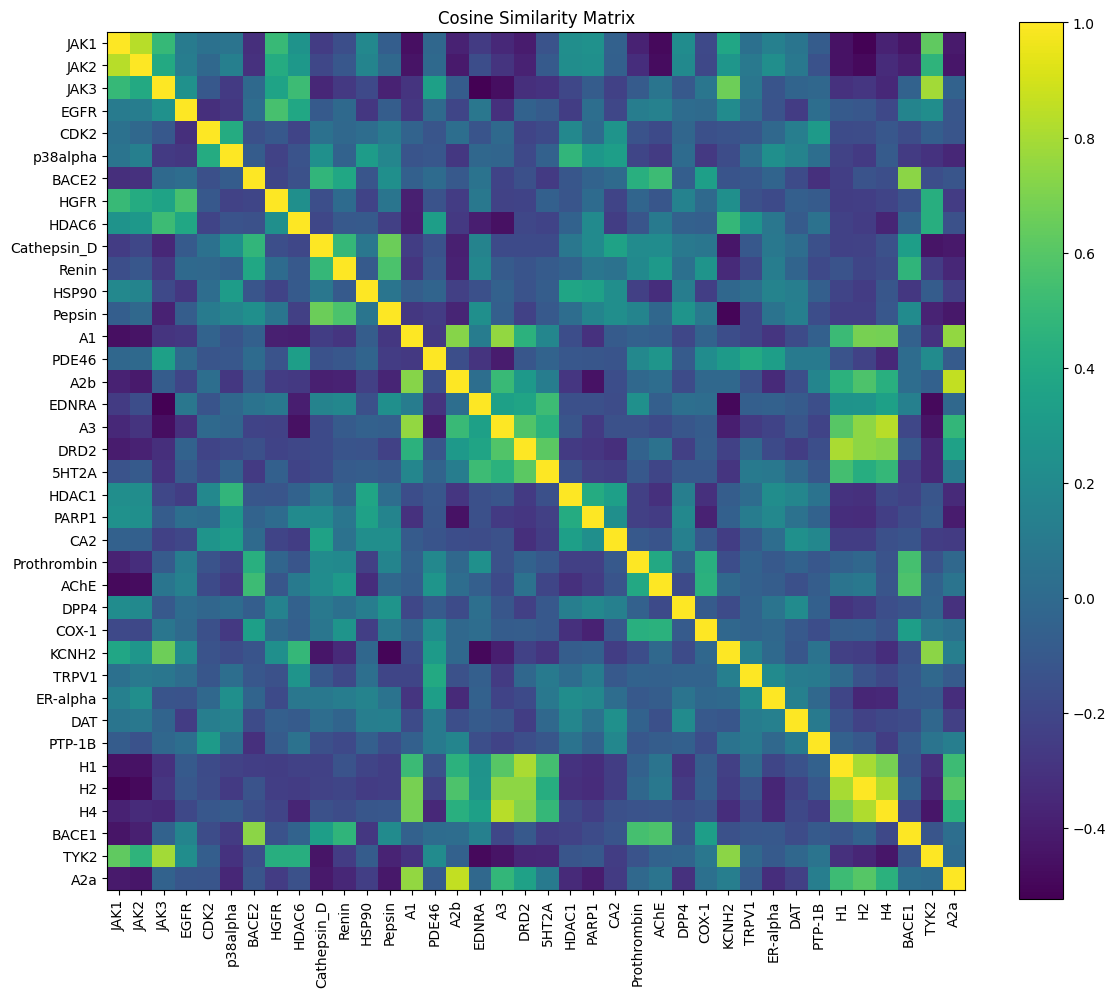

In [44]:
import matplotlib.pyplot as plt

sim_matrix = cosine_similarity_matrix(shift_pooled.cpu())
print(sim_matrix.max(), sim_matrix.min(), sim_matrix.mean(), sim_matrix.std())

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(sim_matrix, cmap="viridis")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

plt.colorbar(im, ax=ax)
plt.title("Cosine Similarity Matrix")
plt.tight_layout()
plt.show()